# S4306 — EDA exhaustive : Gas Sensor Array Drift ⭐

Dataset **dual-usage** à drift capteur **réel** (UCI, Vergara 2012) : 16 capteurs × 8 descripteurs
= 128 features, **6 gaz**, **10 batches temporels** sur 36 mois (drift incrémental).
Cette EDA feature-level distingue explicitement deux axes :

- **structure de classe** → le **gaz** (`_label` ∈ 1..6) ;
- **dérive temporelle** → le **batch** (`_segment` ∈ 0..9).

Tout sort du loader `DriftDataset` + de `characterization.json` (S4303) — **aucun chiffre en dur**.
Exécutable de bout en bout via `nbconvert` (skip gracieux si `data/raw/` absent).

In [1]:
import json, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.feature_selection import mutual_info_classif

# Racine projet (remonte jusqu'à pyproject.toml — robuste au CWD nbconvert)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # les loaders utilisent des chemins relatifs à la racine du dépôt

from src.figures.style import apply_style          # déclenche matplotlib.use("Agg")
from src.utils.reproducibility import set_seed
from src.utils.config_loader import load_config
from src.data.gas_sensor_drift_dataset import load
from src.evaluation.eda_plots import (
    plot_label_distribution, plot_histograms_by_label, plot_boxplots_by_label,
    plot_violin_by_label, plot_kde_by_label, plot_temporal_by_label,
    plot_boxplots_by_group_and_label, plot_violin_by_group_and_label,
    plot_kde_by_group_and_label,
)
from src.evaluation.feature_space_plots import fit_pca2d, fit_tsne2d, plot_feature_space_2d

set_seed(42)          # reproductibilité (échantillonnage, t-SNE, MI)
apply_style("slide")  # rcParams cohérents avec la galerie S4305

CONFIG  = ROOT / "configs/gas_sensor_drift_config.yaml"
CHAR    = ROOT / "experiments/exp_S43_drift_char/gas_sensor_drift/characterization.json"
FIG_DIR = ROOT / "notebooks/cl_eval/drift_datasets/figures/eda/gas_sensor_drift"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(str(CONFIG))
RAW = ROOT / cfg["data"]["raw_path"]


def load_char():
    """Résumé S4303 (None si absent — pas de crash)."""
    if not CHAR.exists():
        return None
    return json.loads(CHAR.read_text(encoding="utf-8"))


def show(fig, name):
    """Sauvegarde le PNG puis l'affiche inline (backend Agg → display(Image), cf. S4305)."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(str(path)))


def scatter_by_category(ax, coords, cats, title, legend_title,
                        cmap="tab10", continuous=False):
    """Scatter 2D coloré par catégorie (helper local : plot_feature_space_2d est
    limité aux labels binaires + 3 noms de domaine figés Pump/Turbine/Compressor ;
    pour l'axe DÉRIVE multi-catégorie on reprend le scatter inline de eda_paderborn)."""
    cats = np.asarray(cats)
    if continuous:
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=cats, cmap=cmap,
                        s=6, alpha=0.4, linewidths=0)
        cb = ax.figure.colorbar(sc, ax=ax)
        cb.set_label(legend_title)
    else:
        cm = plt.get_cmap(cmap)
        for i, u in enumerate(sorted(np.unique(cats))):
            m = cats == u
            ax.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.4, linewidths=0,
                       color=cm(i % cm.N), label=f"{legend_title} {u}")
        ax.legend(fontsize=8, markerscale=2, ncol=2, loc="best")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2"); ax.grid(alpha=0.3)


char = load_char()
DATA_OK = RAW.exists()
if not DATA_OK:
    display(Markdown(
        f"> ⚠️ **Données brutes absentes** (`{RAW}`). Notebook en mode dégradé : "
        f"les figures dépendant de `data/raw/` sont omises proprement. "
        f"Le résumé S4303 (JSON) reste lisible ci-dessous."))
if char is None:
    display(Markdown("> ⚠️ Caractérisation S4303 absente — lancer `scripts/characterize_drift.py`."))

✅ Seed fixé à 42


## 1. Chargement & vue d'ensemble

In [2]:
if DATA_OK:
    ds = load(str(CONFIG))
    df = pd.DataFrame(ds.X, columns=ds.feature_names)
    df["_label"] = ds.y                       # gaz 1..6
    seg = np.zeros(ds.n_samples, dtype=int)
    for i, (s, e) in enumerate(ds.segments):
        seg[s:e] = i
    df["_segment"] = seg                      # batch 0..9
    df["_t"] = np.arange(ds.n_samples)        # ordre temporel préservé
    TOP = [f["feature"] for f in char["features_most_drifted"][:5]]  # capteurs les + dérivés
    print(f"X={ds.X.shape} | {len(ds.segments)} batches | "
          f"{df['_label'].nunique()} gaz | drift_type={ds.drift_type}")
    # Mapping capteur -> feature (16 capteurs × 8 descripteurs)
    mapping = pd.DataFrame({
        "feature": TOP,
        "capteur": [int(n.split('_')[-1]) // 8 for n in TOP],
        "descripteur": [int(n.split('_')[-1]) % 8 for n in TOP],
    })
    display(Markdown("**Capteurs les plus dérivés (mapping 16×8) :**"))
    display(mapping)

X=(13910, 128) | 10 batches | 6 gaz | drift_type=incremental


**Capteurs les plus dérivés (mapping 16×8) :**

,feature,capteur,descripteur
0,sensor_feat_36,4,4
1,sensor_feat_39,4,7
2,sensor_feat_100,12,4
3,sensor_feat_108,13,4
4,sensor_feat_44,5,4


In [3]:
if char is not None:
    top = ", ".join(f"`{f['feature']}` (KS={f['mean_ks']:.2f})"
                    for f in char["features_most_drifted"][:5])
    maha = char["series"]["mahalanobis"]
    peak = max(range(len(maha)), key=lambda k: maha[k])
    align = char.get("alignment_score")
    align_txt = "`null` (pas de vérité-terrain ponctuelle)" if align is None else f"{align:.0f}"
    display(Markdown(
        f"**Résumé S4303 — Gas Sensor**\n\n"
        f"- Drift confirmé : `{char['drift_type_confirmed']}` · "
        f"{char['n_samples']} échantillons × {char['n_features']} features\n"
        f"- Axe dérive (batches) : {len(ds.segments) if DATA_OK else 'N/A'} segment(s)\n"
        f"- Features les plus dérivées : {top}\n"
        f"- Pic Mahalanobis à la fenêtre centrée sur `t={char['window_centers'][peak]}` "
        f"(magnitude {maha[peak]:.1f})\n"
        f"- Score d'alignement pic↔vérité-terrain : {align_txt}"))

**Résumé S4303 — Gas Sensor**

- Drift confirmé : `incremental` · 13910 échantillons × 128 features
- Axe dérive (batches) : 10 segment(s)
- Features les plus dérivées : `sensor_feat_36` (KS=0.64), `sensor_feat_39` (KS=0.63), `sensor_feat_100` (KS=0.59), `sensor_feat_108` (KS=0.56), `sensor_feat_44` (KS=0.55)
- Pic Mahalanobis à la fenêtre centrée sur `t=750` (magnitude 838.9)
- Score d'alignement pic↔vérité-terrain : 242

## 2. Statistiques descriptives (par batch et par gaz)

In [4]:
if DATA_OK:
    display(Markdown("**Moyenne des capteurs les plus dérivés — par batch (dérive) :**"))
    display(df.groupby("_segment")[TOP].mean().round(2))
    display(Markdown("**Moyenne des capteurs les plus dérivés — par gaz (structure de classe) :**"))
    display(df.groupby("_label")[TOP].mean().round(2))
    print(f"Valeurs manquantes : {int(df[ds.feature_names].isna().sum().sum())}")

**Moyenne des capteurs les plus dérivés — par batch (dérive) :**

,sensor_feat_36,sensor_feat_39,sensor_feat_100,sensor_feat_108,sensor_feat_44
_segment,,,,,
0,-0.00,-0.00,-0.00,0.00,0.00
1,1.78,-0.95,1.57,1.25,1.26
2,2.28,-0.25,2.82,2.15,1.49
3,3.07,-3.25,5.04,4.08,2.35
4,3.33,-0.96,4.47,3.50,2.38
5,1.72,-1.35,2.57,2.07,1.35
6,1.82,-1.62,2.21,1.82,1.28
7,1.54,-1.44,1.13,0.78,1.01
8,1.89,-1.80,1.00,0.70,1.12


**Moyenne des capteurs les plus dérivés — par gaz (structure de classe) :**

,sensor_feat_36,sensor_feat_39,sensor_feat_100,sensor_feat_108,sensor_feat_44
_label,,,,,
1,3.28,-1.81,4.48,3.58,2.42
2,1.82,-0.77,2.34,1.92,1.30
3,1.35,-1.16,1.25,1.07,0.80
4,1.66,-1.05,1.60,1.18,1.02
5,1.51,-1.62,1.44,1.02,0.91
6,1.17,-1.07,1.12,0.81,0.71


Valeurs manquantes : 0


## 3. Distribution du label (gaz) et effectifs par batch

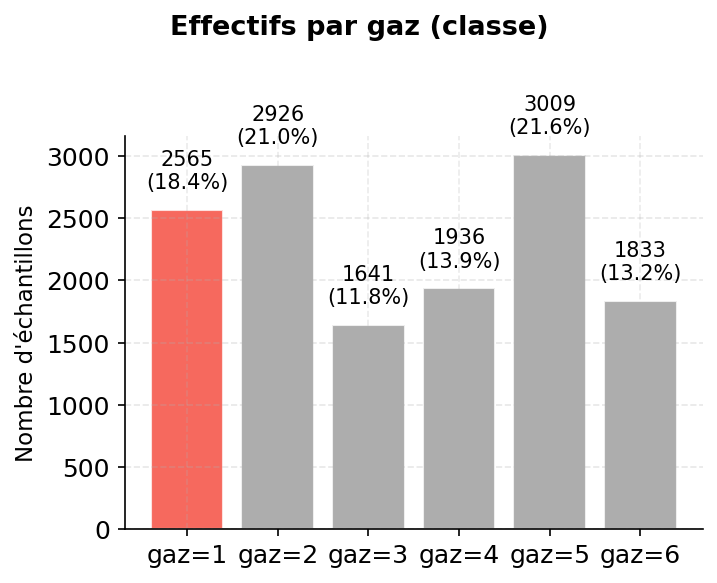

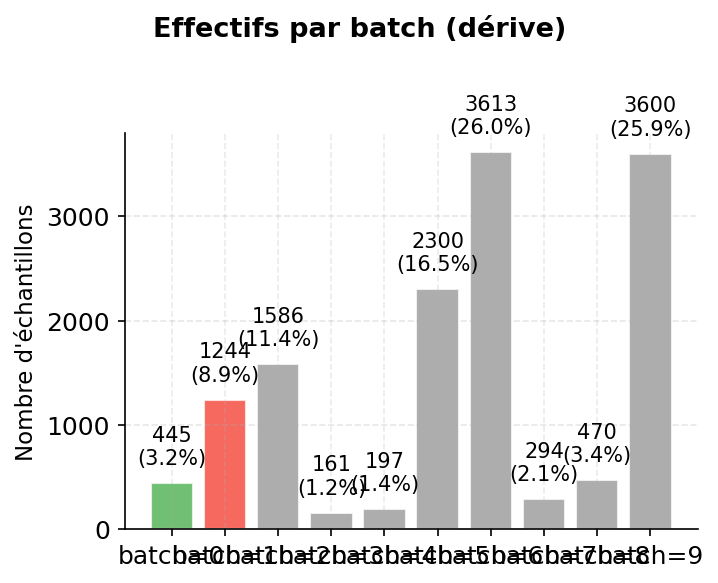

In [5]:
if DATA_OK:
    show(plot_label_distribution(df, "_label", label_name="gaz",
                                 title="Effectifs par gaz (classe)"), "label_dist_gaz")
    # Réutilise le même helper en comptant les batches (label_col=_segment)
    show(plot_label_distribution(df, "_segment", label_name="batch",
                                 title="Effectifs par batch (dérive)"), "label_dist_batch")

## 4. Distributions de features — structure de classe (gaz) vs dérive (batch)

`*_by_label` colore/groupe par **gaz** ; `*_by_group_and_label` ajoute l'axe **batch**.

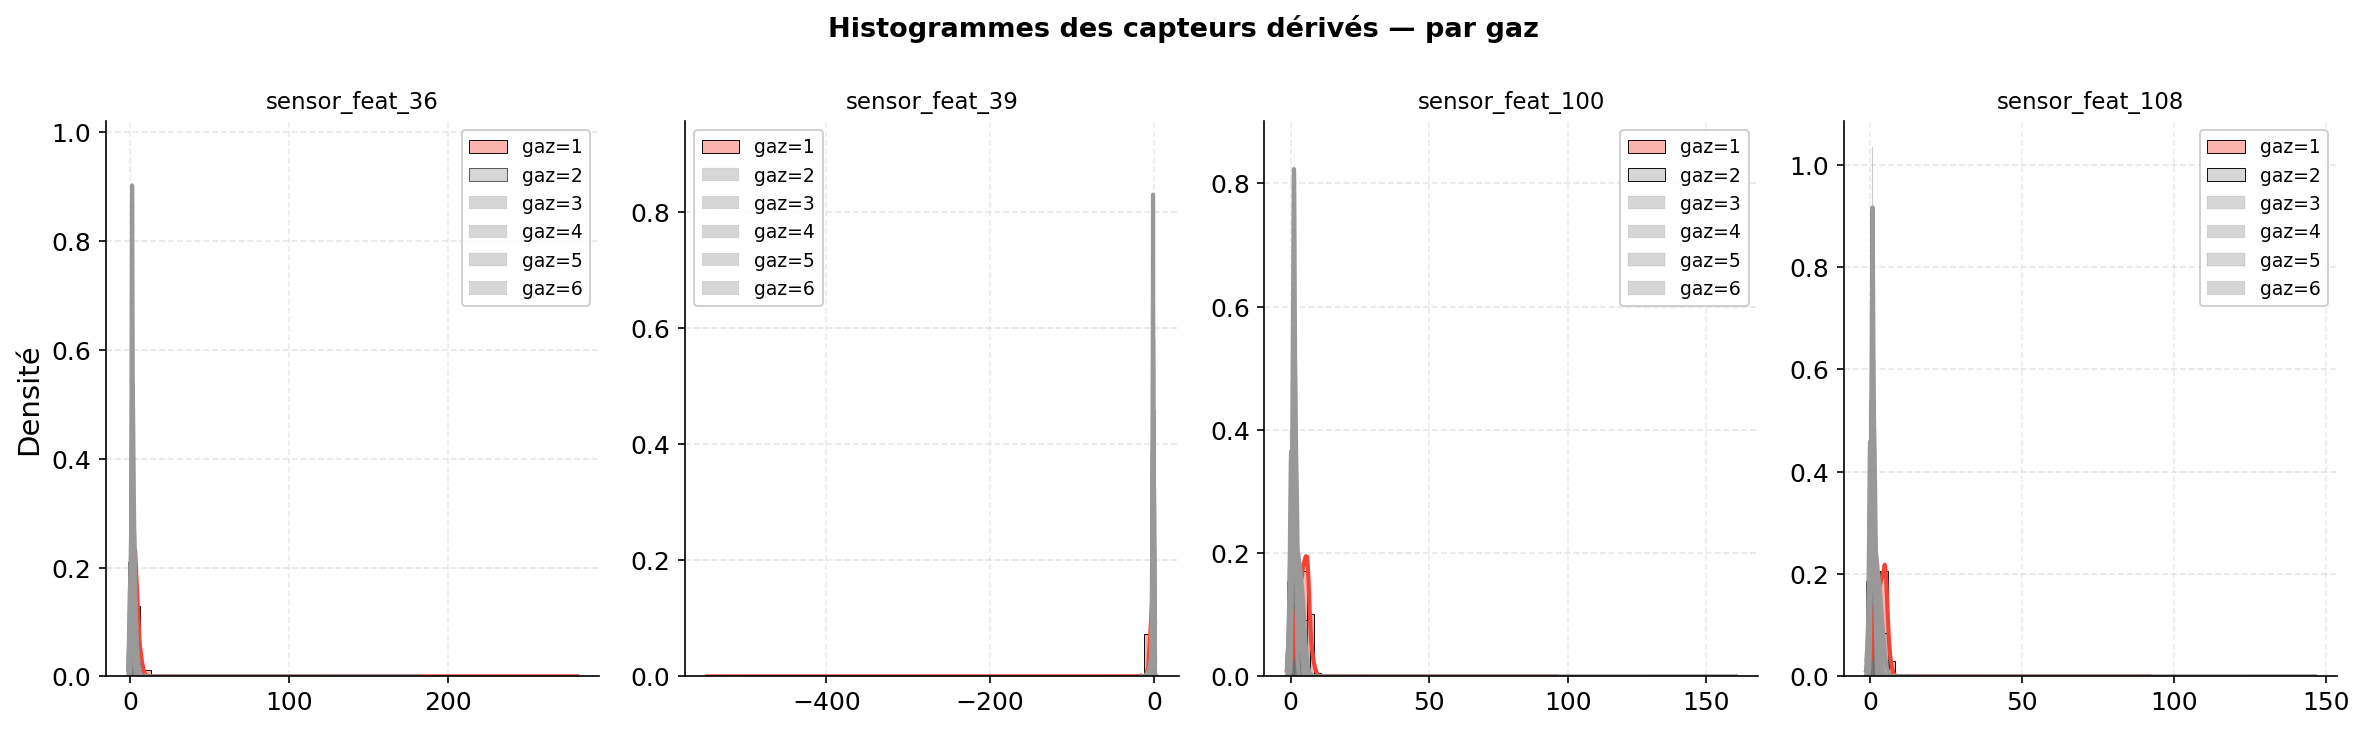

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

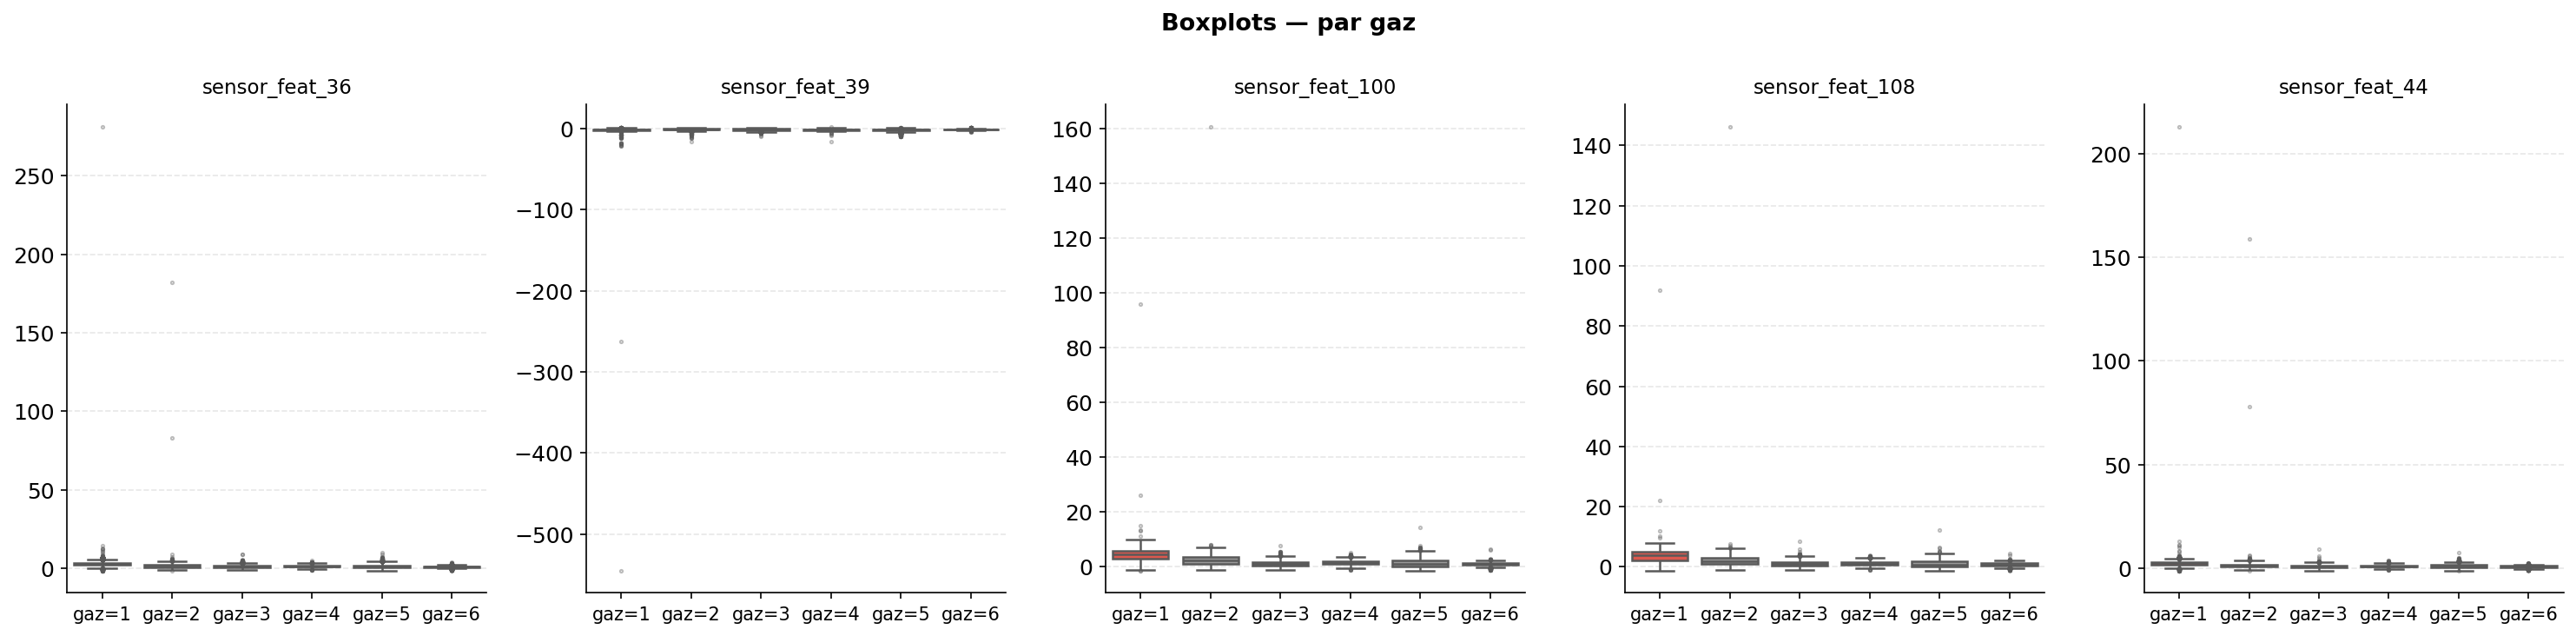

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

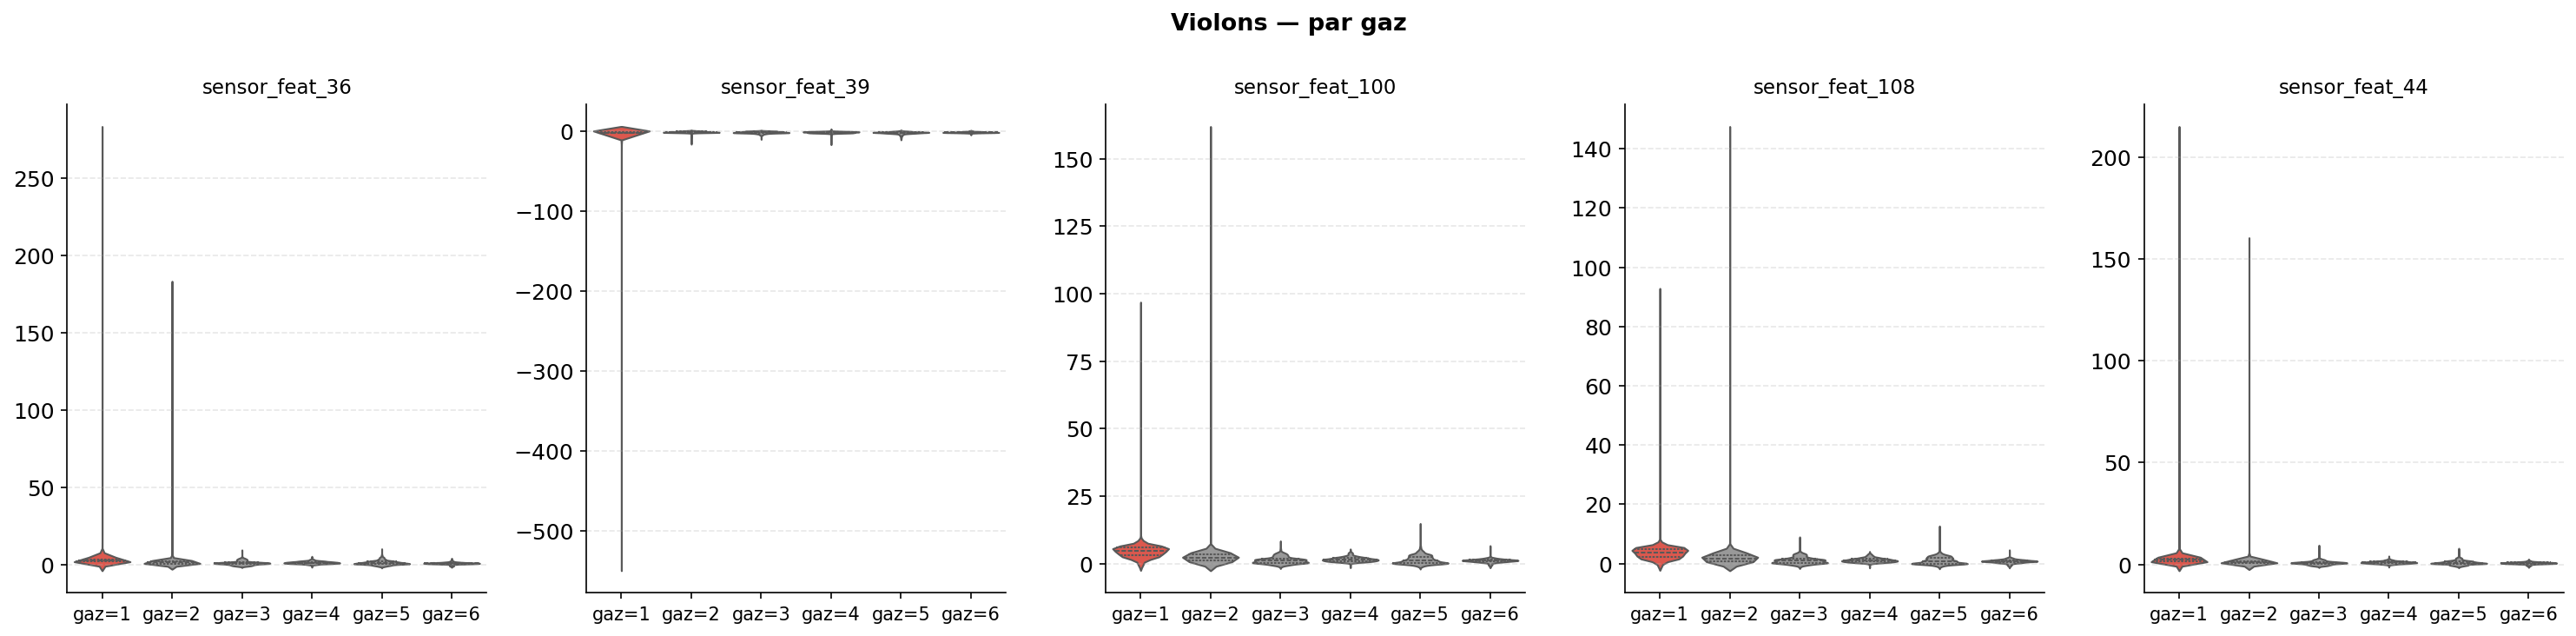

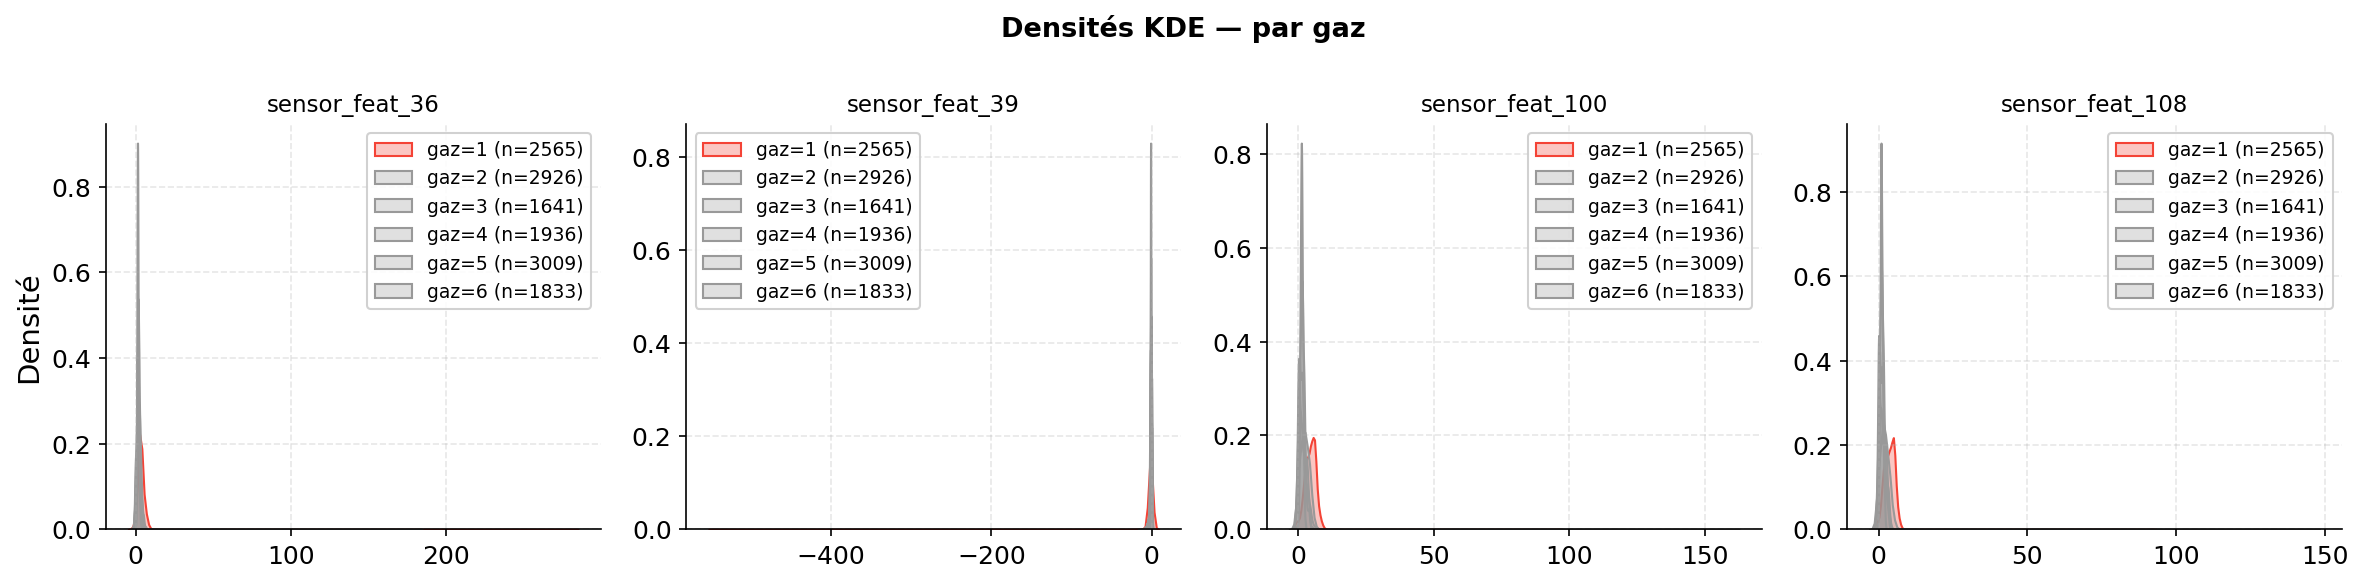

In [6]:
if DATA_OK:
    show(plot_histograms_by_label(df, TOP[:4], "_label", label_name="gaz",
         title="Histogrammes des capteurs dérivés — par gaz"), "hist_by_gaz")
    show(plot_boxplots_by_label(df, TOP[:5], "_label", label_name="gaz",
         title="Boxplots — par gaz"), "box_by_gaz")
    show(plot_violin_by_label(df, TOP[:5], "_label", label_name="gaz",
         title="Violons — par gaz"), "violin_by_gaz")
    show(plot_kde_by_label(df, TOP[:4], "_label", label_name="gaz",
         title="Densités KDE — par gaz"), "kde_by_gaz")

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:560: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:569: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:560: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:569: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/le

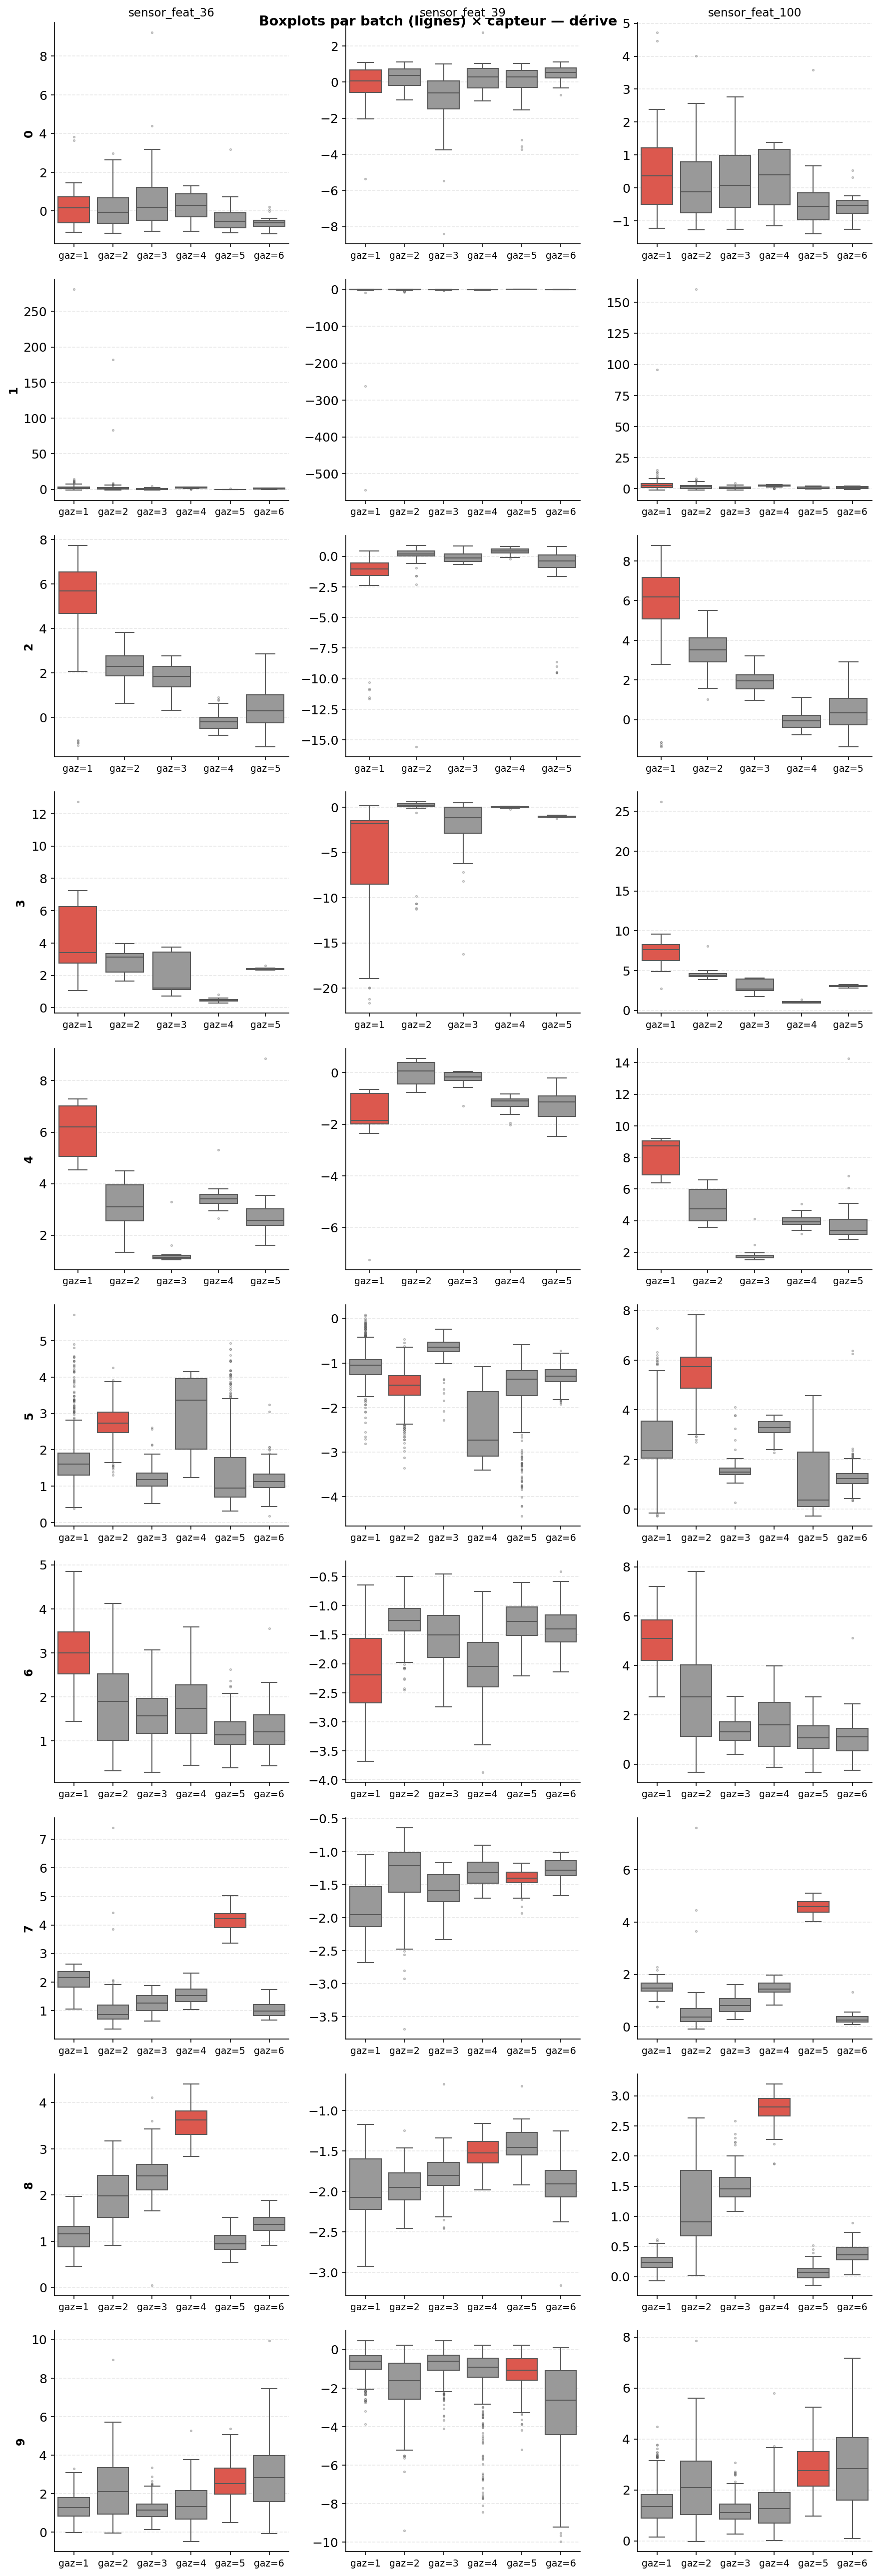

In [7]:
if DATA_OK:
    # Grille batch × feature : la dérive se lit ligne à ligne (batch 0 -> 9)
    show(plot_boxplots_by_group_and_label(df, TOP[:3], "_label", "_segment",
         label_name="gaz", title="Boxplots par batch (lignes) × capteur — dérive"),
         "box_batch_gaz")

## 5. Trajectoires de réponse capteur sur les 10 batches (dérive incrémentale)

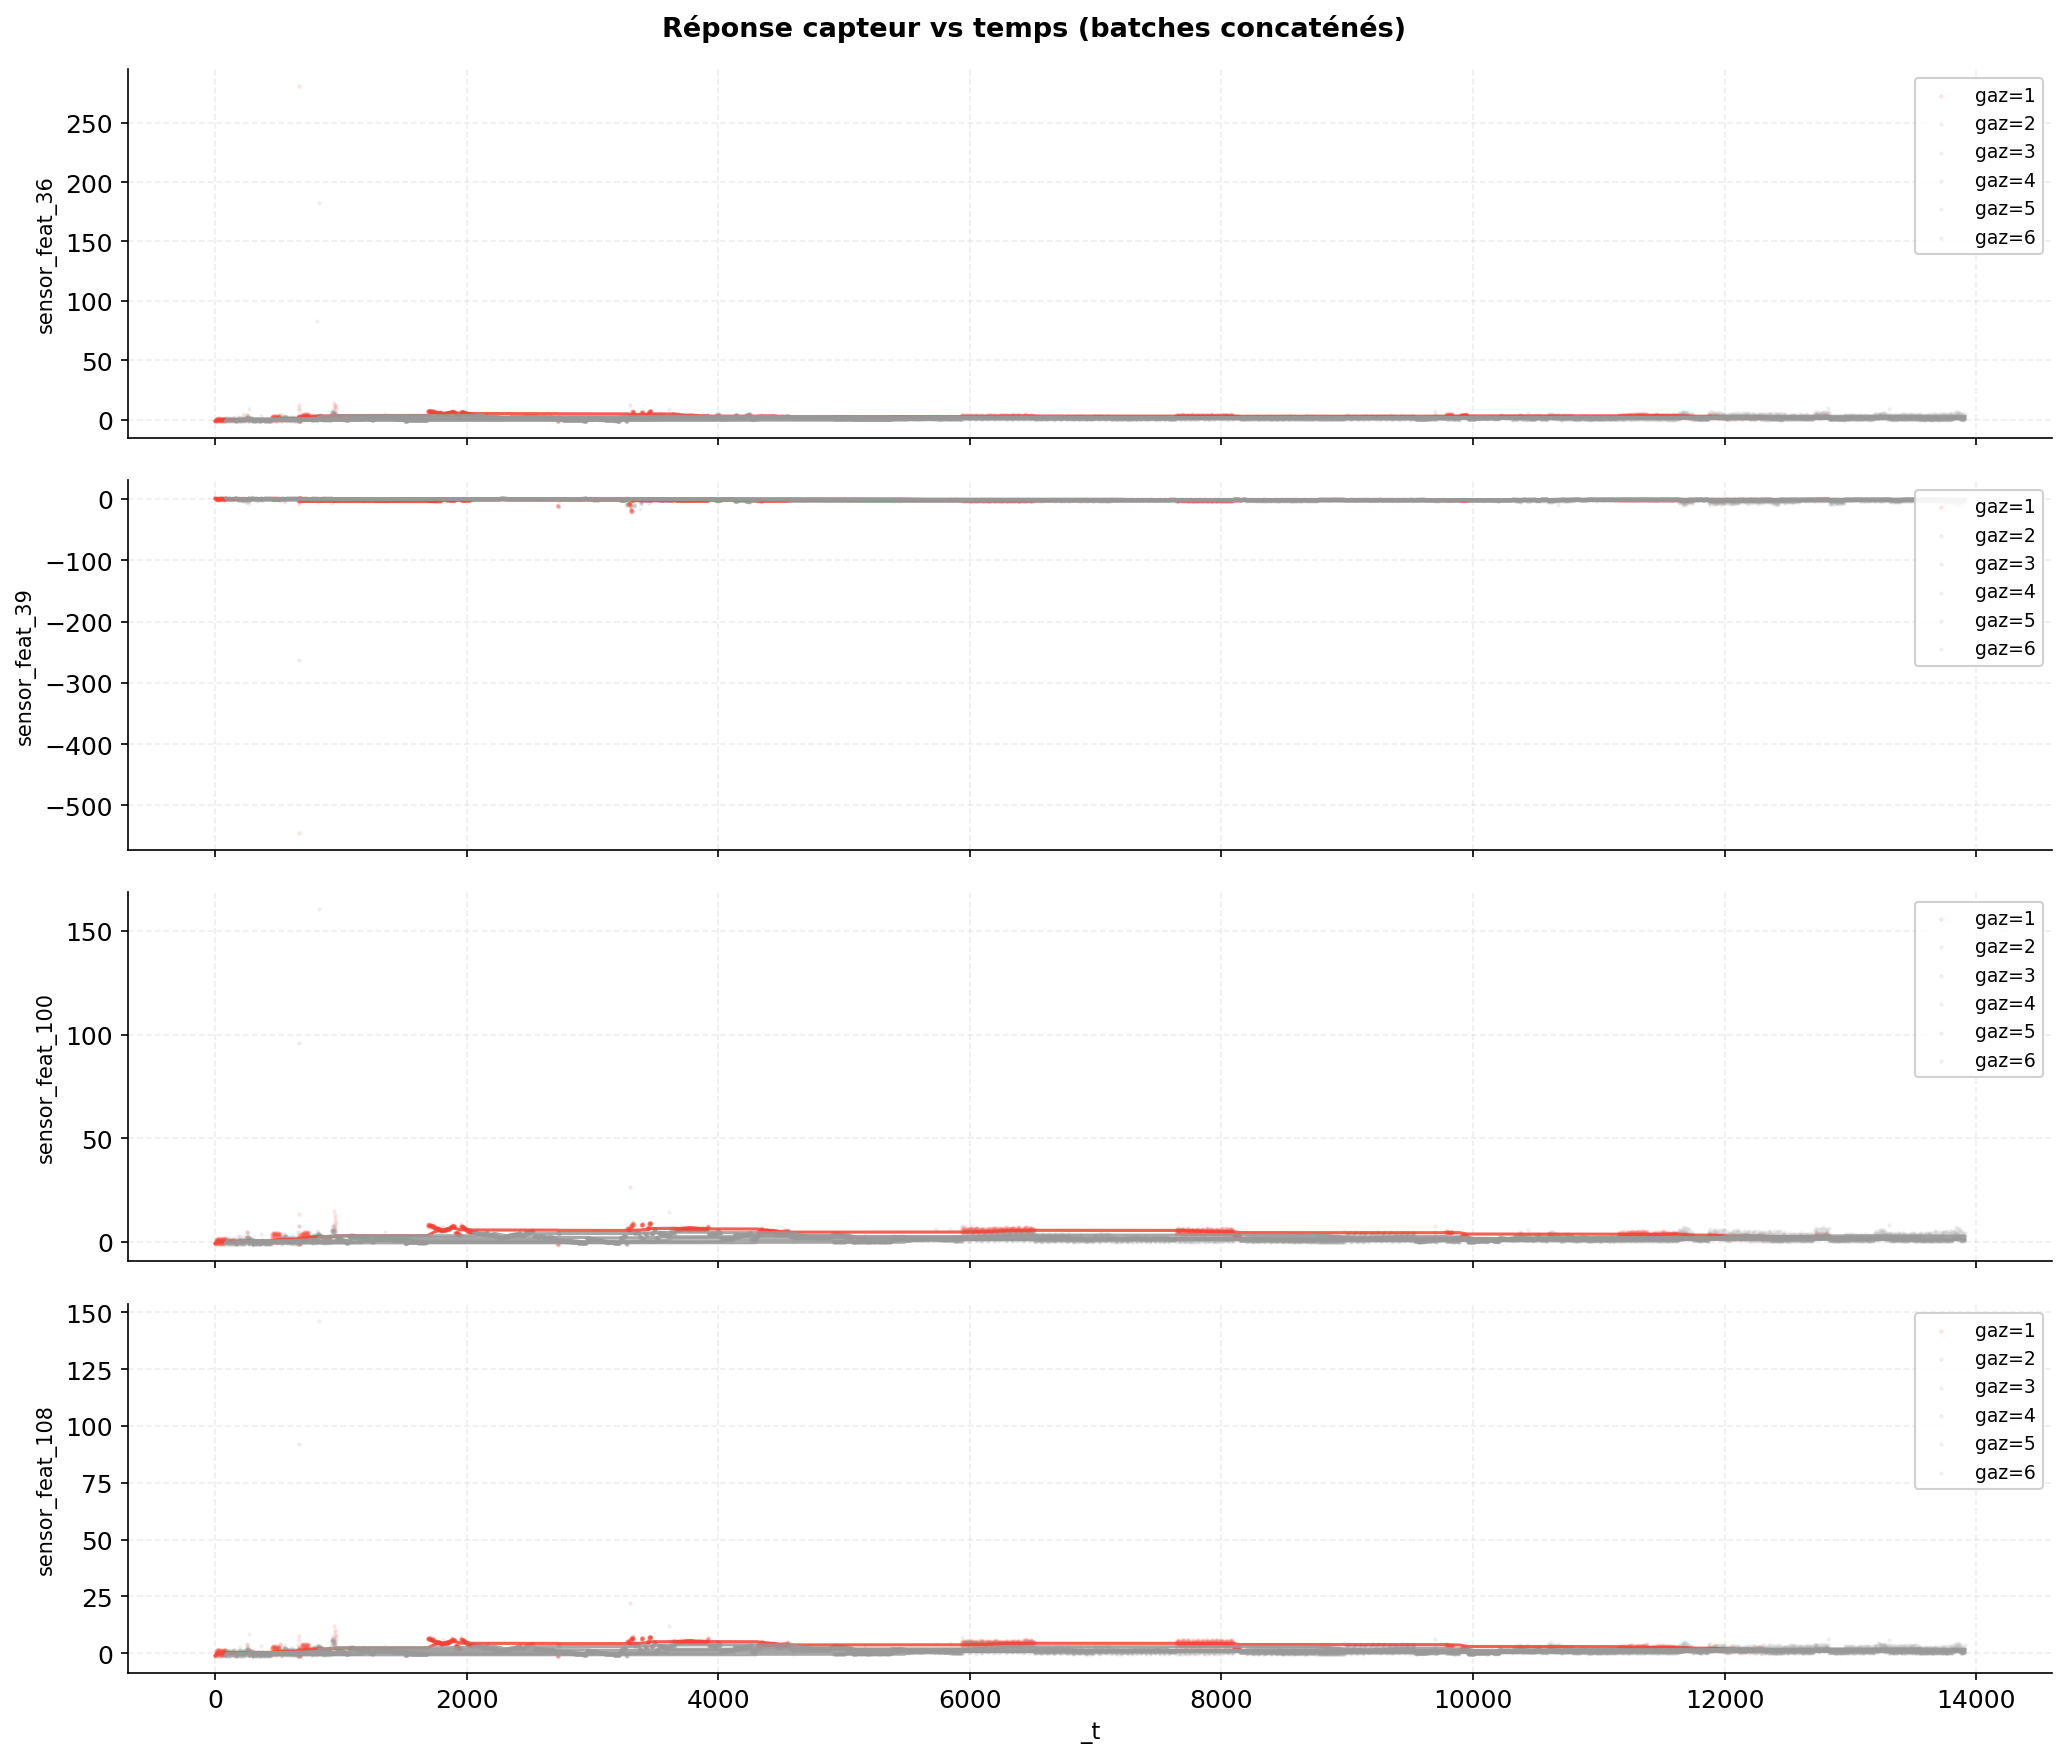

In [8]:
if DATA_OK:
    show(plot_temporal_by_label(df, TOP[:4], "_label", "_t", label_name="gaz",
         rolling_window=200, title="Réponse capteur vs temps (batches concaténés)"),
         "temporal_gaz")

## 6. Corrélations inter-capteurs (redondance / familles)

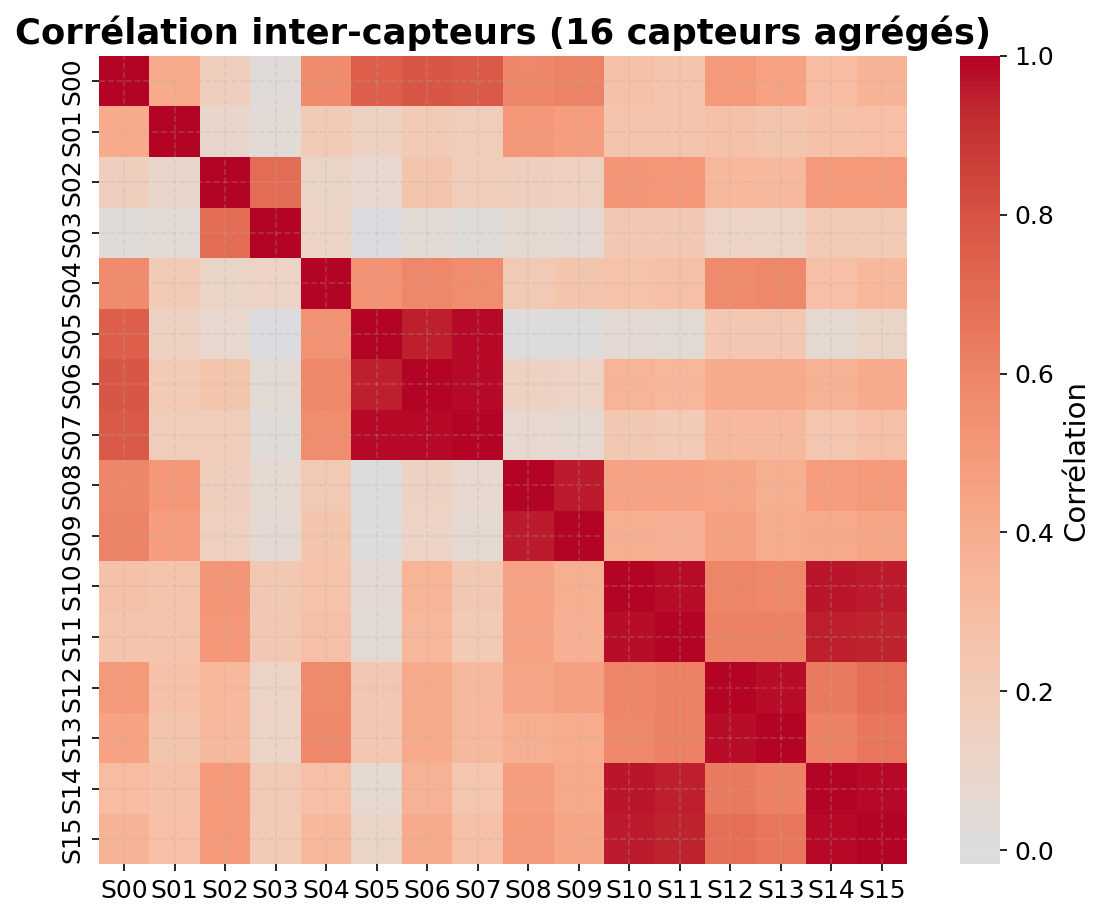

In [9]:
if DATA_OK:
    # Agrège les 8 descripteurs par capteur -> matrice 16×16 lisible
    sensor_sig = pd.DataFrame({
        f"S{s:02d}": df[[f"sensor_feat_{8*s+d}" for d in range(8)]].mean(axis=1)
        for s in range(16)
    })
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(sensor_sig.corr(), cmap="coolwarm", center=0, ax=ax,
                square=True, cbar_kws={"label": "Corrélation"})
    ax.set_title("Corrélation inter-capteurs (16 capteurs agrégés)", fontweight="bold")
    show(fig, "corr_capteurs")

## 7. Projection 2D — déplacement du nuage (batch) puis séparabilité (gaz)

Sous-échantillonnage documenté (graine 42) pour rendre t-SNE tractable sur 13 910×128.

Projection sur 3000 échantillons sous-échantillonnés (graine 42).


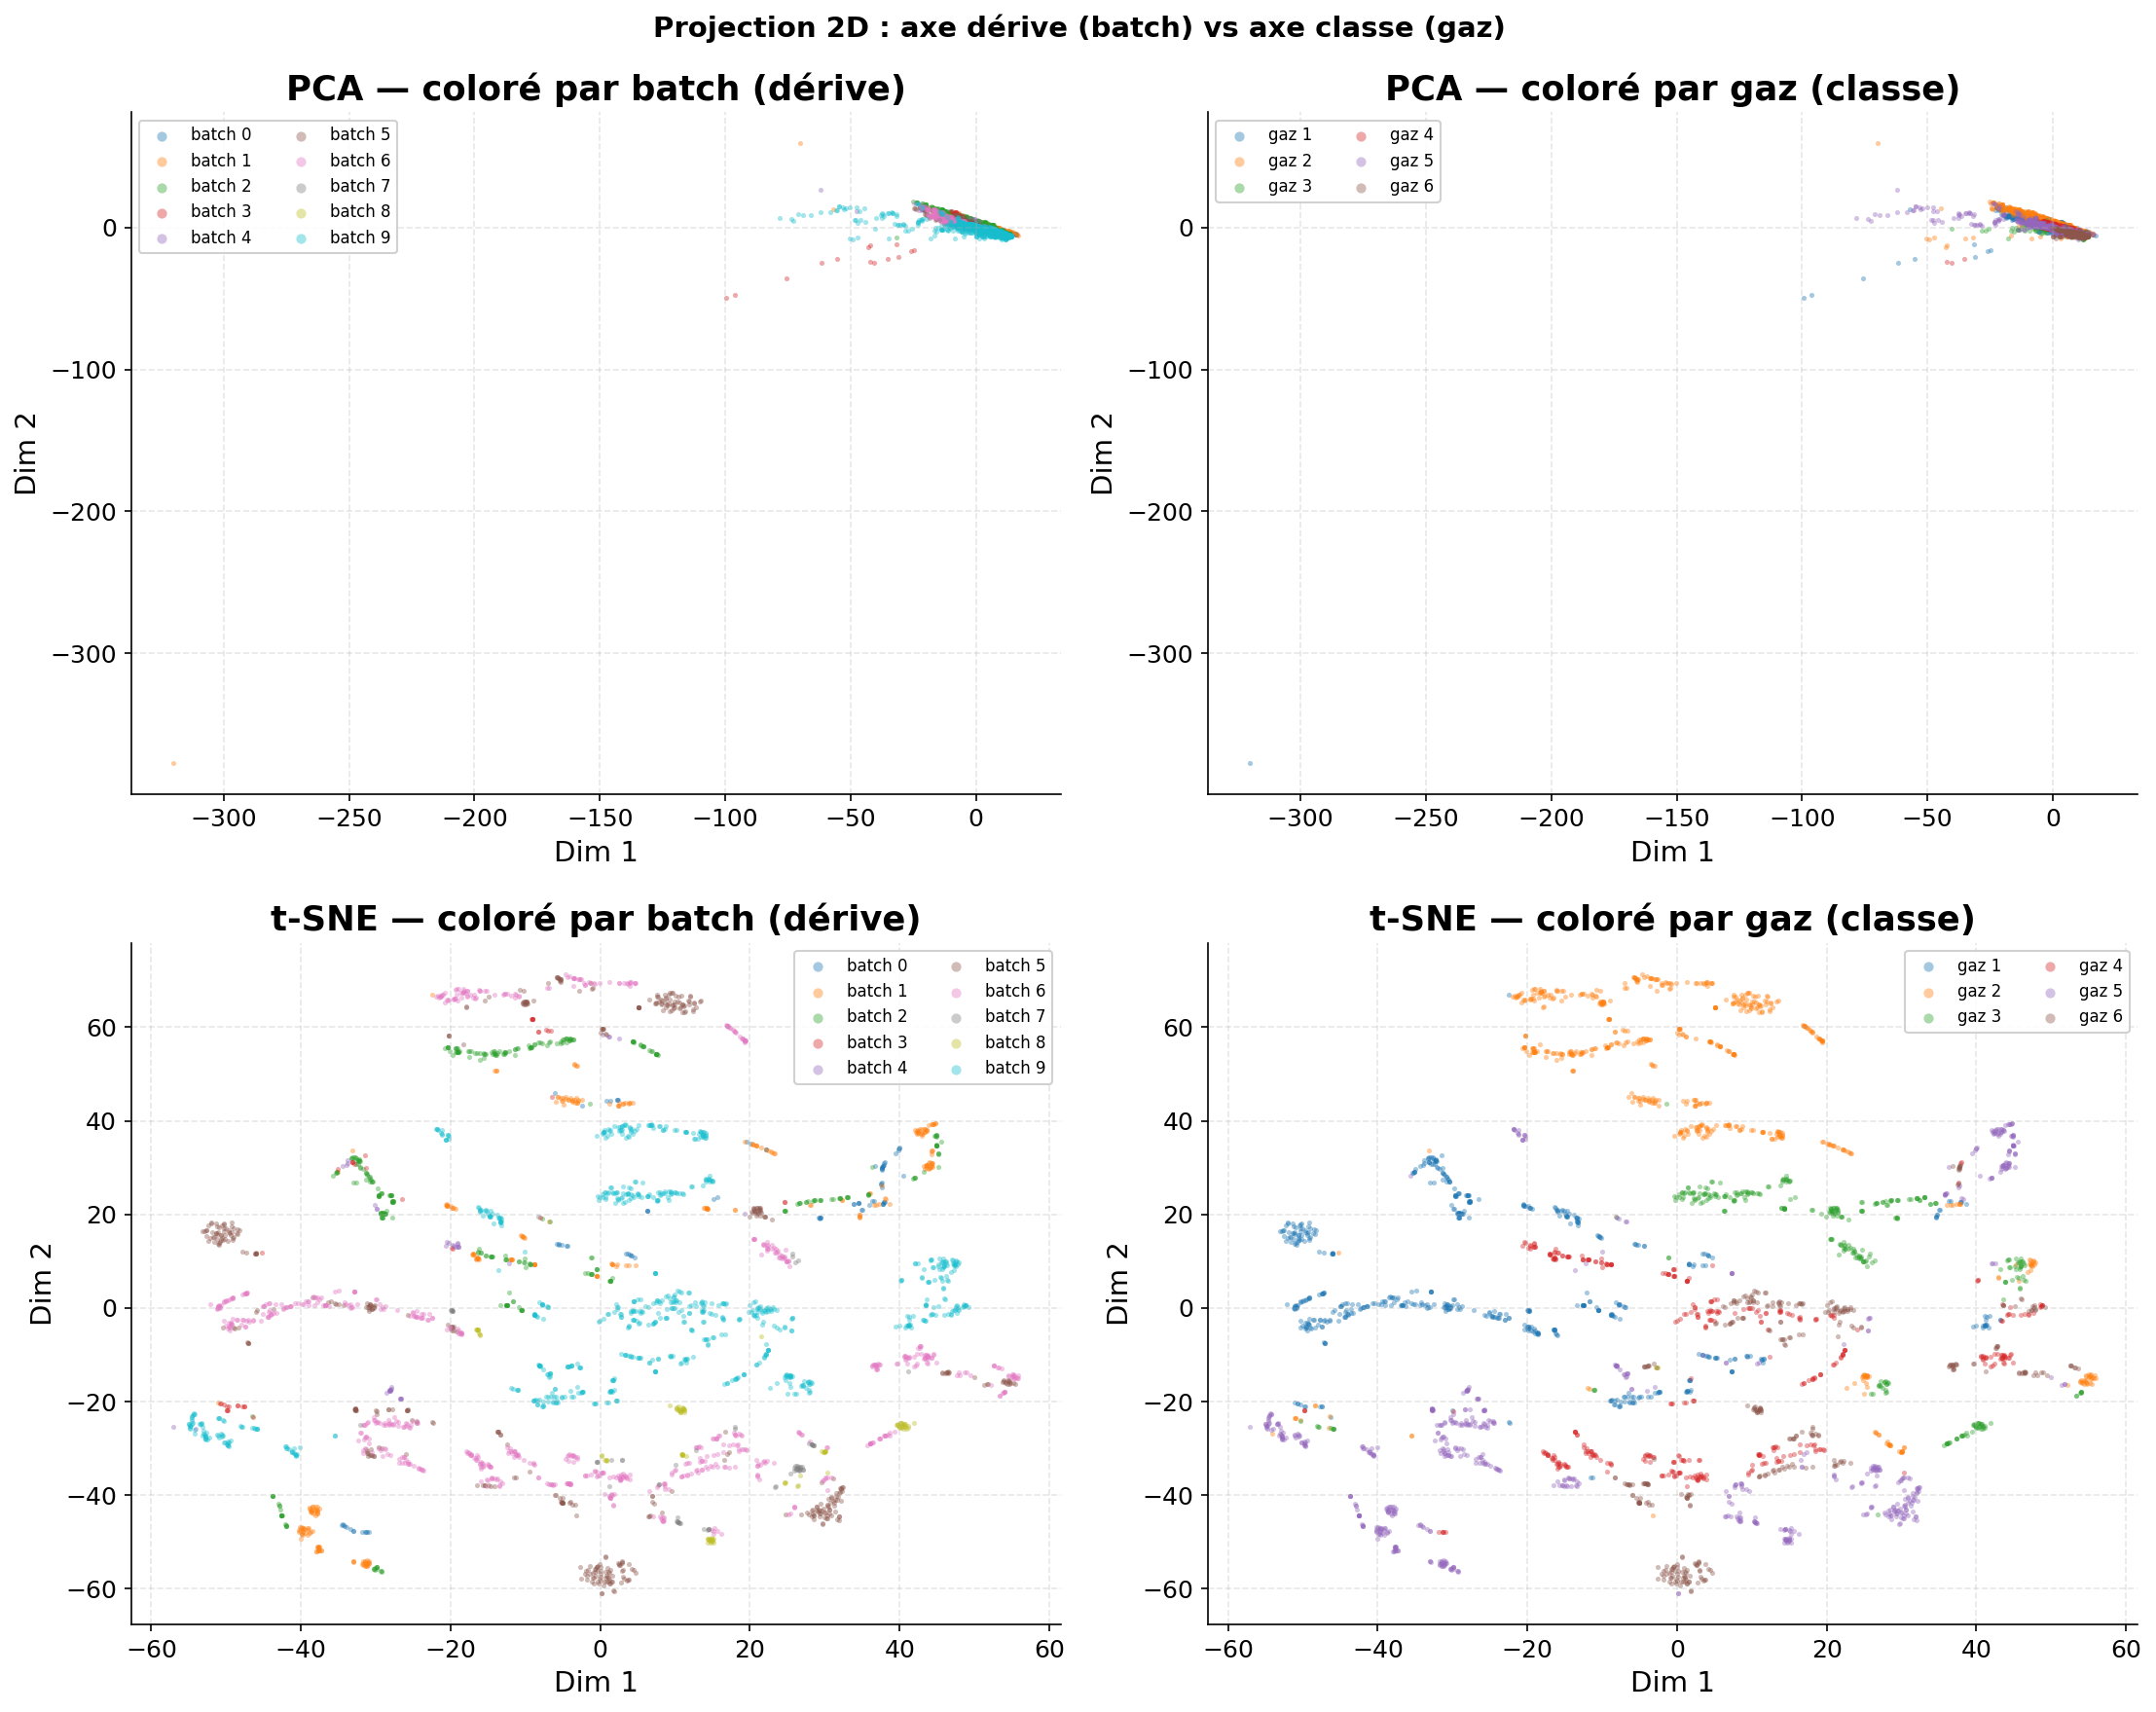

In [10]:
if DATA_OK:
    rng = np.random.default_rng(42)
    n_sub = min(ds.n_samples, 3000)
    idx = rng.choice(ds.n_samples, size=n_sub, replace=False)
    Xs, seg_s, y_s = ds.X[idx], seg[idx], ds.y[idx]
    _, pca_xy = fit_pca2d(Xs)
    _, tsne_xy = fit_tsne2d(Xs, perplexity=30.0)
    print(f"Projection sur {n_sub} échantillons sous-échantillonnés (graine 42).")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    scatter_by_category(axes[0, 0], pca_xy, seg_s, "PCA — coloré par batch (dérive)", "batch",
                        cmap="tab10")
    scatter_by_category(axes[0, 1], pca_xy, y_s, "PCA — coloré par gaz (classe)", "gaz",
                        cmap="tab10")
    scatter_by_category(axes[1, 0], tsne_xy, seg_s, "t-SNE — coloré par batch (dérive)", "batch",
                        cmap="tab10")
    scatter_by_category(axes[1, 1], tsne_xy, y_s, "t-SNE — coloré par gaz (classe)", "gaz",
                        cmap="tab10")
    fig.suptitle("Projection 2D : axe dérive (batch) vs axe classe (gaz)",
                 fontsize=14, fontweight="bold")
    fig.tight_layout()
    show(fig, "projection_2d")

## 8. Magnitude de dérive par fenêtre (Mahalanobis, S4303)

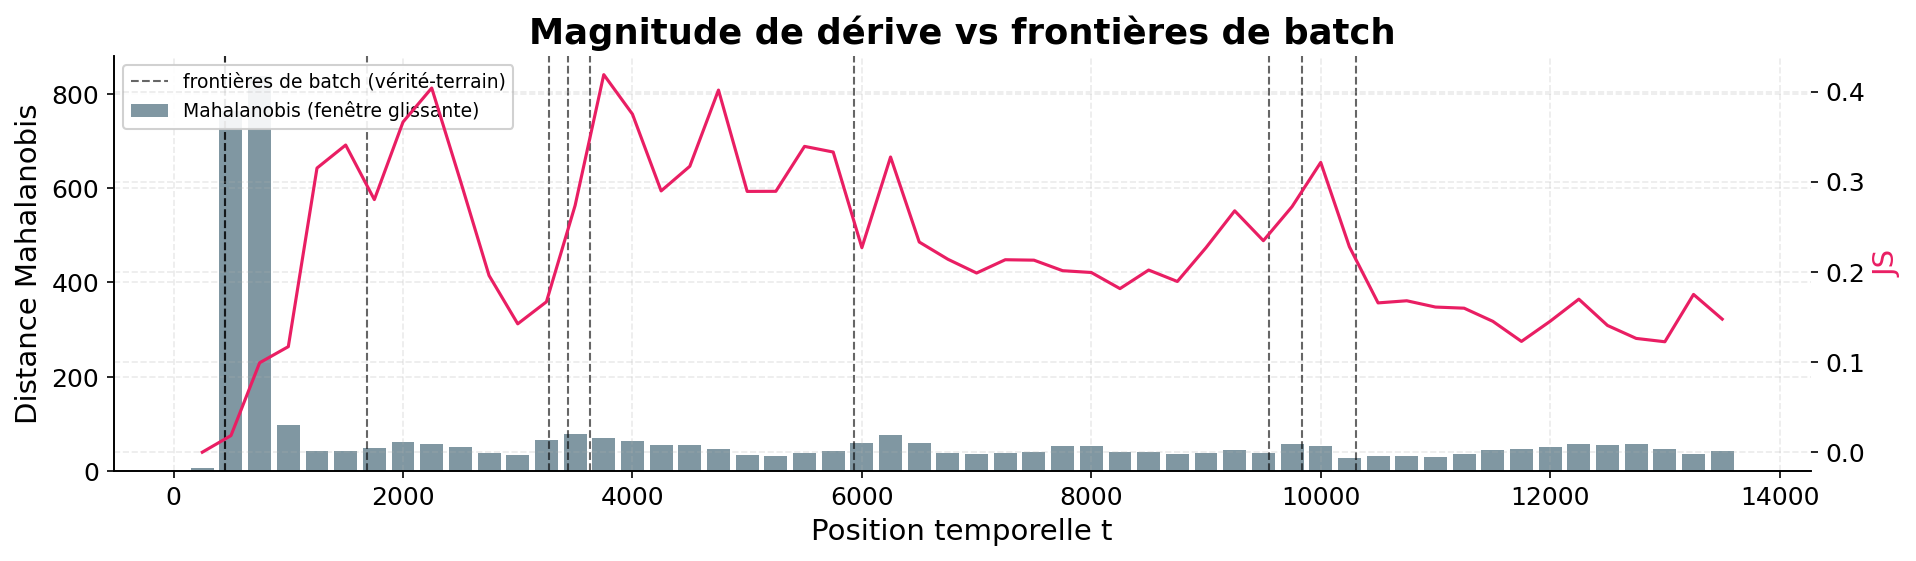

In [11]:
if char is not None:
    wc = char["window_centers"]
    maha = char["series"]["mahalanobis"]
    js = char["series"]["js"]
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(wc, maha, width=char["stride"] * 0.8, color="#607D8B", alpha=0.8,
           label="Mahalanobis (fenêtre glissante)")
    ax2 = ax.twinx()
    ax2.plot(wc, js, color="#E91E63", lw=1.5, label="Jensen-Shannon")
    ax2.set_ylabel("JS", color="#E91E63")
    for dp in char["drift_points"]:
        ax.axvline(dp, color="black", ls="--", lw=1, alpha=0.6)
    ax.axvline(char["drift_points"][0], color="black", ls="--", lw=1, alpha=0.6,
               label="frontières de batch (vérité-terrain)")
    ax.set_xlabel("Position temporelle t"); ax.set_ylabel("Distance Mahalanobis")
    ax.set_title("Magnitude de dérive vs frontières de batch", fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    fig.tight_layout()
    show(fig, "drift_magnitude")

## 9. Résumé pour le Sprint 44

- **Détecteur de drift** : dérive incrémentale de capteur → une fenêtre glissante (≈ `window_size`
  S4303) capte la magnitude ; le pic Mahalanobis est aligné sur les frontières de batch.
- **Features informatives** : les capteurs les plus dérivés (`features_most_drifted`) portent le signal
  de dérive — candidats à un sous-ensemble embarqué.
- **Dimension d'entrée** : 128 features → note **Gap 2/3** — coûteux pour un détecteur non-supervisé sur
  MCU (cf. constat S44 : le coût non-supervisé croît avec la dimensionnalité) ; envisager réduction
  (sélection capteurs / PCA) avant portage.